In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs



In [2]:
folder = "data"
files = os.listdir(folder)

test_file = files[1]  # Select the second file for testing
file_path = os.path.join(folder, test_file)
df = pd.read_csv(file_path, header=0, delimiter=" ")
print(f"Loaded file: {test_file} with shape {df.shape}")
print(df.head())

Loaded file: 000574_XYZ_HY02131_V1.txt with shape (446844, 3)
          Lat (DMS)         Long (DMS)  Mean (m)
0  53-35-27.321937N  004-36-50.001932E     26.39
1  53-35-27.307267N  004-36-51.089269E     26.39
2  53-35-27.292594N  004-36-52.176606E     26.39
3  53-35-27.277918N  004-36-53.263943E     26.39
4  53-35-27.263239N  004-36-54.351279E     26.39


In [3]:
def split_dms(dms_str):
    [degrees, minutes, seconds] = dms_str.split('-')
    direction = seconds[-1]
    seconds = seconds[:-1]
    degrees, minutes, seconds = map(float, [degrees, minutes, seconds])
    return degrees, minutes, seconds, direction



def dms_to_dd(degrees, minutes, seconds, direction):
    dd = float(degrees) + float(minutes)/60 + float(seconds)/(60*60)
    if direction in ['S', 'W']:
        dd *= -1
    return dd

def northing_to_lat(northing):
    # Approximate conversion from UTM northing to latitude
    return northing / 111320.0


In [4]:
df['Lat'] = df.iloc[:, 0].apply(lambda x: dms_to_dd(*split_dms(x)))
df['Lon'] = df.iloc[:, 1].apply(lambda x: dms_to_dd(*split_dms(x)))


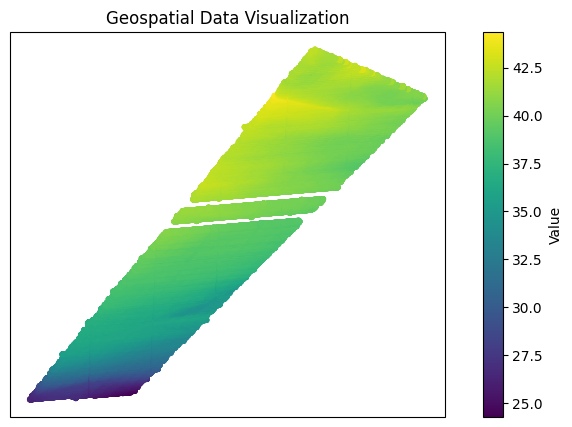

In [5]:
# plot 3d using cartopy

plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
sc = ax.scatter(df['Lon'], df['Lat'], c=df.iloc[:, 2], cmap='viridis', s=10, transform=ccrs.PlateCarree())
plt.colorbar(sc, label='Value') 
plt.title('Geospatial Data Visualization')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [6]:
metadata = pd.read_csv("metadata.csv")
print(metadata.columns)

Index(['Data Set name', 'Discipline', 'Category', 'Variables measured',
       'Data format', 'Data format version', 'Data size',
       'Data Set creation Date', 'Latitude 1', 'Latitude 2', 'Longitude 1',
       'Longitude 2', 'Datum', 'Measuring area type', 'Water depth (m)',
       'Depth reference', 'Minimum instrument depth (m)',
       'Maximum instrument depth (m)', 'Location qualification', 'Start Date',
       'Start time', 'End Date', 'End time', 'Vertical resolution',
       'Vertical resolution unit', 'Instrument / gear type',
       'Track resolution', 'Track resolution unit', 'Frequency',
       'Frequency unit', 'Platform type', 'Cruise name',
       'Alternative cruise name', 'Cruise start Date', 'Station name',
       'Alternative station name', 'Station start Date', 'Originator',
       'Data Holding centre', 'Project name', 'Project type',
       'EDMED references', 'CSR references', 'CSR platform name',
       'CSR platform code', 'Publication references',
       'D

In [4]:
import pickle
from dataloader import dataLoader

os.chdir("C:/Users/Berend.Bouvy/Documents/Thesis-Shell")
with open("data_loaders.pkl", "rb") as f:
    loaders = pickle.load(f)


In [45]:
longs = []
lats = []
for loader in loaders:
    longs.extend(loader.data['Lon'].tolist())
    lats.extend(loader.data['Lat'].tolist())

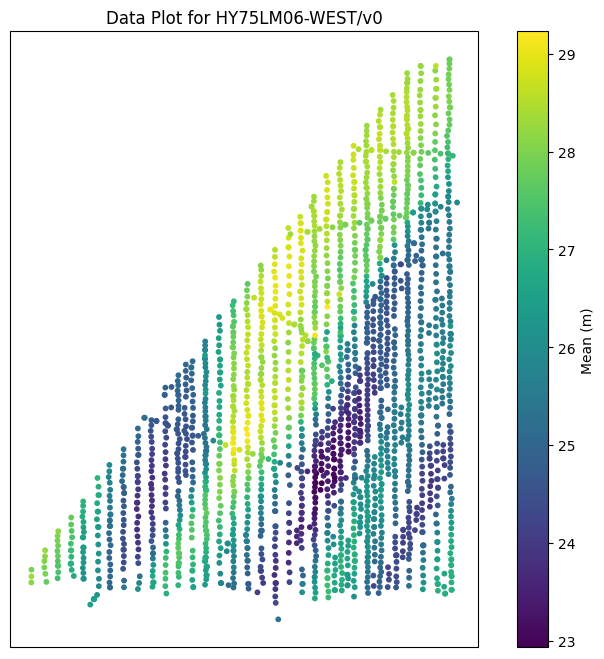

In [4]:
if os.path.exists("plots") == False:
    os.mkdir("plots")
for i in loaders:
    lat1, lat2, lon1, lon2 = i.get_bounding_box()
    
    i.plot_data(save_path=f"plots/{i.metadata['Data Set name']}_plot.png", show=False, bbox=True)
    break
    

In [55]:
names = map(lambda dl: dl.metadata["Data Set name"], loaders)
print(list(names))

['40 MIJL WEST VAN TEXEL', '60 MIJL NOORD-WEST VAN TEXEL', '60 MIJL NOORD-WEST VAN TEXEL', '60 MIJL NOORD-WEST VAN TEXEL', '60 MIJL NOORD-WEST VAN TEXEL', 'BEWESTEN DIEPWATERROUTE', 'Botney Cut', 'Brown Ridge - West Friesland West Friesland ( SW )West Friesland (C)', 'Brown Ridge West Friesland', 'Bruine Bank - Vlieland Gronden', 'CAT1 gebied TE route', 'DW-ROUTE', 'DW-ROUTE', 'DW-ROUTE', 'DW-route off Botney Ground', 'DW-ROUTE TEA KETTLE HOLE', 'East Friesland (E)', 'EAST FRIESLAND TSS OOSTGAAND', 'EAST FRIESLAND TSS WESTGAAND', 'EHR 14 BENOORDEN TERSCHELLING', 'FRIESLAND JUNCTION', 'Friesland Junction', 'Friesland Junction', 'HY93041', 'Klaverbank', 'nabij Diepwaterroute', 'Noord van Terschelling-Geman B', 'Noord van Terschelling-Geman B', 'NOORD-WEST VAN TEXEL', 'NOORD-WEST VAN TEXEL', 'NOORD-WEST VAN TEXEL', 'NOORD-WEST VAN TEXEL', 'Noordelijk deel NCP', 'Noordelijk deel NCP', 'Noordelijk deel NCP', 'NOORDELIJKE DIEPWATERROUTE', 'NOORDELIJKE DIEPWATERROUTE', 'NOORDZEE', 'NOORDZEE',

In [46]:
min_lon = min(longs)
max_lon = max(longs)

min_lat = min(lats)
max_lat = max(lats)
print(f"Longitude range: {min_lon} to {max_lon}")
print(f"Latitude range: {min_lat} to {max_lat}")

Longitude range: 2.773316588920788 to 9.18470226419755
Latitude range: 52.00916655000973 to 54.61926386632794


In [11]:
from coordFunc import convert_northing_easting


In [14]:
for loader in loaders:
    if loader.metadata['CDI-record id'] == 2174832:
        # loader.plot_data(show=True)
        print(loader.metadata['Datum'])
        print(loader.data.head())
        print(convert_northing_easting(loader.data['Northing'][:5], loader.data['Easting'][:5], loader.metadata['Datum']))
        

World Geodetic System 84 / UTM zone 32N (32632)
    Easting   Northing  Mean (m)        Lat       Lon
0  500620.0  5926780.0     30.71  53.489988  9.009345
1  500640.0  5926780.0     30.64  53.489988  9.009646
2  500660.0  5926780.0     30.72  53.489988  9.009948
3  500580.0  5926800.0     30.56  53.490168  9.008742
4  500600.0  5926800.0     30.56  53.490168  9.009043
(array([53.48998846, 53.48998843, 53.48998841, 53.49016828, 53.49016825]), array([9.00934465, 9.00964609, 9.00994753, 9.0087418 , 9.00904325]))


In [9]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("meta/metadata_with_density_flagged.csv")
df[df['rejected'] == 1]


,Data Set name,Discipline,Category,Variables measured,Data format,Data format version,Data size,Data Set creation Date,Latitude 1,Latitude 2,Longitude 1,Longitude 2,Datum,Measuring area type,Water depth (m),Depth reference,Minimum instrument depth (m),Maximum instrument depth (m),Location qualification,Start Date,Start time,End Date,End time,Vertical resolution,Vertical resolution unit,Instrument / gear type,Track resolution,Track resolution unit,Frequency,Frequency unit,Platform type,Cruise name,Alternative cruise name,Cruise start Date,Station name,Alternative station name,Station start Date,Originator,Data Holding centre,Project name,Project type,EDMED references,CSR references,CSR platform name,CSR platform code,Publication references,Data Quality Control Info,Data Distributor,Database reference,Access/ordering of data,Access restriction,CDI-record creation date,CDI-record id,LOCAL_CDI_ID,CDI-partner,point_density(100x100m),rejected
52,Off Botney Ground,Marine geology (DS04)|Terrestrial (DS08),"Gravity, magnetics and bathymetry (G005)|Terre...",Bathymetry and Elevation(MBAN),xyz,1.0,4847721,20221019,2.994389,3.185416,53.486721,53.697048,World Geodetic System 84 / UTM zone 32N (32632),surface (006),NaN,Lowest Astronomical Tide (D01),30.43,41.15,Beyond the 12 NM boundary,20090728,00:00:00,20090816,23:59:59,NaN,NaN,multi-beam echosounders(157),20.0,Metres (ULAA),NaN,NaN,research vessel (31),Opnamebeleidsplan Hydrografie,OBP NLHYD,20000101,HOV,NLHY,20090728.0,"Royal Netherlands Navy, Hydrographic Service (...","Royal Netherlands Navy, Hydrographic Service (...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dutch Standards for Hydrographic Surveys^^2009...,"Royal Netherlands Navy, Hydrographic Service (...",NaN,web data access with registration,Creative Commons Attribution 4.0 International...,20221019,2174832,HY09407_S_mean_totaal/v1,"Royal Netherlands Navy, Hydrographic Service (...",23.812,1
82,TE-route,Marine geology (DS04)|Terrestrial (DS08),"Gravity, magnetics and bathymetry (G005)|Terre...",Bathymetry and Elevation(MBAN),xyz,1.0,1863766,20221110,5.262500,5.523958,53.506248,53.577084,World Geodetic System 84 / UTM zone 31N (32631),surface (006),NaN,Lowest Astronomical Tide (D01),17.24,21.51,Landward side of the 12 NM boundary,20100930,08:00:00,20101007,17:00:00,0.01,Metres (ULAA),multi-beam echosounders(157),20.0,Metres (ULAA),1.0,Days (UTAA),research vessel (31),Opnamebeleidsplan Hydrografie 2010,OBP NLHYD,20100101,HOV,NLHY,20100930.0,"Royal Netherlands Navy, Hydrographic Service (...","Royal Netherlands Navy, Hydrographic Service (...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,QI_Horizontal^^2010-10-07^^3||QI_Vertical^^201...,"Royal Netherlands Navy, Hydrographic Service (...",NaN,web data access with registration,Creative Commons Attribution 4.0 International...,20221110,3455421,HY10115/v0,"Royal Netherlands Navy, Hydrographic Service (...",24.052,1


In [8]:
df[df['point_density(100x100m)'] < 20][:3]

,Data Set name,Discipline,Category,Variables measured,Data format,Data format version,Data size,Data Set creation Date,Latitude 1,Latitude 2,...,Data Distributor,Database reference,Access/ordering of data,Access restriction,CDI-record creation date,CDI-record id,LOCAL_CDI_ID,CDI-partner,point_density(100x100m),rejected
0,40 MIJL WEST VAN TEXEL,Marine geology (DS04)|Terrestrial (DS08),"Gravity, magnetics and bathymetry (G005)|Terre...",Bathymetry and Elevation(MBAN),xyz,1.0,89413,20250205,3.530917,3.758809,...,"Royal Netherlands Navy, Hydrographic Service (...",NaN,web data access with registration,Creative Commons Attribution 4.0 International...,20250205,3819933,HY75LM06-WEST/v0,"Royal Netherlands Navy, Hydrographic Service (...",1.134,0
1,60 MIJL NOORD-WEST VAN TEXEL,Marine geology (DS04)|Terrestrial (DS08),"Gravity, magnetics and bathymetry (G005)|Terre...",Bathymetry and Elevation(MBAN),xyz,1.0,106591,20250204,4.012130,4.237902,...,"Royal Netherlands Navy, Hydrographic Service (...",NaN,web data access with registration,Creative Commons Attribution 4.0 International...,20250204,3814901,HY75LM02A-OOST/v0,"Royal Netherlands Navy, Hydrographic Service (...",1.138,0
2,60 MIJL NOORD-WEST VAN TEXEL,Marine geology (DS04)|Terrestrial (DS08),"Gravity, magnetics and bathymetry (G005)|Terre...",Bathymetry and Elevation(MBAN),xyz,1.0,12175,20250205,3.202500,3.324759,...,"Royal Netherlands Navy, Hydrographic Service (...",NaN,web data access with registration,Creative Commons Attribution 4.0 International...,20250205,3819931,HY75LM01-WEST/v0,"Royal Netherlands Navy, Hydrographic Service (...",1.151,0


In [43]:
from dataloader import dataLoader
metadata = pd.read_csv("meta/metadata_with_density_flagged2.csv")
dl = dataLoader(metadata[metadata['rejected'] == 1].iloc[0])

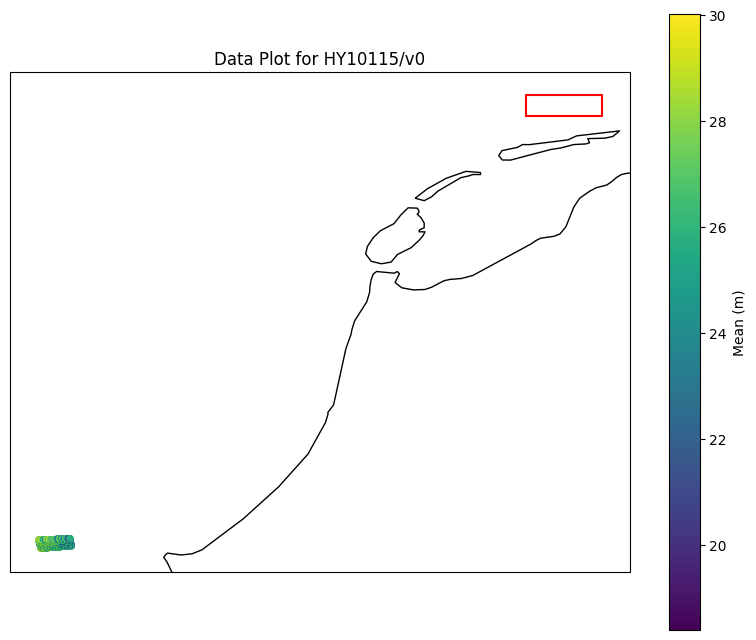

In [44]:
dl.plot_data(bbox=True, show=True)

In [45]:
dl.data.head()

,Easting,Northing,Mean (m),Lat,Lon
0,540120.0,5762220.0,26.06,52.009175,3.584531
1,540140.0,5762220.0,26.06,52.009174,3.584822
2,540160.0,5762220.0,26.40,52.009172,3.585114
3,540180.0,5762220.0,29.03,52.009171,3.585405
4,540200.0,5762220.0,29.44,52.009169,3.585697


In [41]:
metadata.to_csv("meta/metadata_with_density_flagged2.csv", index=False)

In [47]:
sum(metadata['point_density(100x100m)']>20)

74

In [8]:
meta = pd.read_csv("meta/metadata_with_density_flagged2.csv")

loaders_accepted = []
for idx, row in meta.iterrows():
    if row['rejected'] == 0 and row['point_density(100x100m)'] > 20:
        dl = dataLoader(row)
        loaders_accepted.append(dl)
print(f"Number of accepted loaders: {len(loaders_accepted)}")

Number of accepted loaders: 73


In [9]:
# save the reduced list of loaders to a pickle file
with open("data_loaders_accepted.pkl", "wb") as f:
    pickle.dump(loaders_accepted, f)    